In [1]:
import pandas as pd
import numpy as np

# 🧪 自动生成线粒体基因筛选原始脏数据
homework_data = {
    "Gene_Symbol": ["DMT1", "MFRN1", "MFRN2", "  ", "DMT1", "FTL", "SLC25A37", "MFRN1"],
    "Control_Exp": [12.5, 45.2, np.nan, None, 12.5, 120.4, 8.1, 45.2],
    "Treated_Exp": [3.1, "8.4", 15.6, None, 3.1, 118.2, 75.4, 8.4],
    "Treatment_Drug": ["Erastin", "Gefitinib", "Imatinib", None, "Erastin", "Aspirin", "Ferrostatin-1", "Gefitinib"],
    "Cell_Line": ["HeLa", "HepG2", "HeLa", None, "HeLa", "HepG2", "HeLa", "HepG2"]
}
pd.DataFrame(homework_data).to_csv("mitochondria_raw_data.csv", index=False)
print("📂 [军火送达] 专属作业盲盒 mitochondria_raw_data.csv 已空投至你的本地！")

📂 [军火送达] 专属作业盲盒 mitochondria_raw_data.csv 已空投至你的本地！


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import re
# 清洗表格
df = pd.read_csv("mitochondria_raw_data.csv")
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.dropna()
df = df.drop_duplicates()

In [3]:
df

,Gene_Symbol,Control_Exp,Treated_Exp,Treatment_Drug,Cell_Line
0,DMT1,12.5,3.1,Erastin,HeLa
1,MFRN1,45.2,8.4,Gefitinib,HepG2
5,FTL,120.4,118.2,Aspirin,HepG2
6,SLC25A37,8.1,75.4,Ferrostatin-1,HeLa


*等一下，SLC25A37怎么混进来了？？*

In [4]:
df = df.replace('SLC25A37', 'MFRN1')

In [6]:
df = df.astype({"Control_Exp": float, "Treated_Exp": float})

In [8]:
df["Fold_Change"] = df["Treated_Exp"] / df["Control_Exp"]
df

,Gene_Symbol,Control_Exp,Treated_Exp,Treatment_Drug,Cell_Line,Fold_Change
0,DMT1,12.5,3.1,Erastin,HeLa,0.248000
1,MFRN1,45.2,8.4,Gefitinib,HepG2,0.185841
5,FTL,120.4,118.2,Aspirin,HepG2,0.981728
6,MFRN1,8.1,75.4,Ferrostatin-1,HeLa,9.308642


In [11]:
import requests
import json
import time
def fetch_Molecular_Formula(Treatment_Drug):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{Treatment_Drug}/property/MolecularFormula/JSON"
    try:
        response = requests.get(url, timeout=5)
        data = response.json()

        molecular_formula = data['PropertyTable']['Properties'][0]['MolecularFormula']
        return molecular_formula
    except Exception as e:
        return "Not Found"
    
time.sleep(1)
df['Molecular_Formula'] = df['Treatment_Drug'].apply(fetch_Molecular_Formula)
df

,Gene_Symbol,Control_Exp,Treated_Exp,Treatment_Drug,Cell_Line,Fold_Change,Molecular_Formula
0,DMT1,12.5,3.1,Erastin,HeLa,0.248000,C30H31ClN4O4
1,MFRN1,45.2,8.4,Gefitinib,HepG2,0.185841,C22H24ClFN4O3
5,FTL,120.4,118.2,Aspirin,HepG2,0.981728,C9H8O4
6,MFRN1,8.1,75.4,Ferrostatin-1,HeLa,9.308642,C15H22N2O2


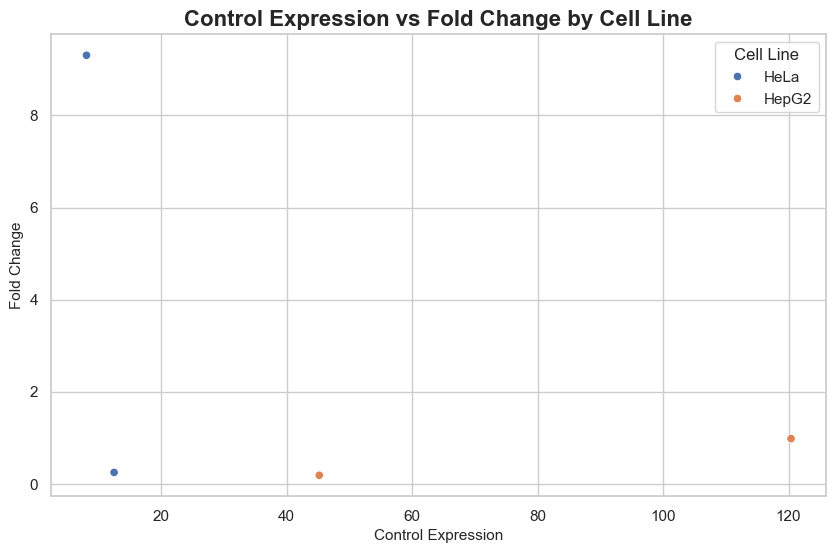

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Control_Exp", y="Fold_Change",hue="Cell_Line")
plt.title("Control Expression vs Fold Change by Cell Line", fontsize=16, fontweight='bold')
plt.xlabel("Control Expression", fontsize=11)
plt.ylabel("Fold Change", fontsize=11)
plt.legend(title="Cell Line")
plt.show()

In [14]:
df.to_excel("mitochondria_raw_data.xlsx", index=False)